# Unit06_Linear_Equations | 線性聯立方程式之求解

本 Notebook 示範如何以 **SciPy** 為主要工具求解線性聯立方程式，並介紹各種求解器的使用時機與化工應用案例。

## 學習目標
- 以矩陣形式 $\mathbf{Ax} = \mathbf{b}$ 表示線性聯立方程式，並以 rank 判定解的性質
- 依系統類型（唯一解 / 無窮多解 / 無解）選擇適當的 SciPy 求解器
- 應用線性代數工具於化工物料平衡與能量平衡問題
- 識別病態系統並評估數值穩定性

---
### 0. 環境設定

In [14]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit06_Linear_Equations'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit06'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit06
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Linear_Equations
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Linear_Equations\figs


---
### 1. 載入套件

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# SciPy 線性代數模組 (本單元主要工具)
from scipy import linalg
from scipy import sparse
from scipy.sparse import linalg as sp_linalg

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 線性聯立方程式基礎

#### 2.1 矩陣形式與秩判定

線性聯立方程式寫成矩陣形式 $\mathbf{Ax} = \mathbf{b}$ 後,需先判定解的性質再選擇求解策略。

**判定規則:**

| rank(A) vs rank([A\|b]) | rank(A) vs n | 解的類型 |
|-----------------------|-------------|---------|
| `rank(A) == rank([A|b])` | `rank(A) == n` | 唯一解 |
| `rank(A) == rank([A|b])` | `rank(A) < n`  | 無窮多解(低確定) |
| `rank(A) < rank([A|b])`  | —              | 無解(過確定,矛盾) |

In [16]:
def check_system(A, b, show_augmented=True):
    """
    判定線性聯立方程式 Ax = b 的解的性質
    
    Parameters
    ----------
    A : array-like, 係數矩陣
    b : array-like, 右端向量
    show_augmented : bool, 是否顯示擴充矩陣
    
    Returns
    -------
    str: 'unique' / 'infinite' / 'no_solution'
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float).ravel()
    Ab = np.column_stack([A, b])
    
    m, n = A.shape
    rank_A  = np.linalg.matrix_rank(A)
    rank_Ab = np.linalg.matrix_rank(Ab)
    
    print(f"矩陣大小: {m} × {n}  (m 個方程式，n 個未知數)")
    print(f"rank(A)        = {rank_A}")
    print(f"rank([A | b])  = {rank_Ab}")
    print(f"n (未知數個數) = {n}")
    
    if rank_A < rank_Ab:
        status = '無解'
        detail = 'overdetermined / inconsistent'
    elif rank_A == rank_Ab == n:
        status = '唯一解'
        detail = 'well-determined'
    else:
        status = f'無窮多解（自由度 = {n - rank_A}）'
        detail = 'underdetermined'
    
    print(f"\n→ 解的性質: {status}  [{detail}]")
    
    if show_augmented:
        print("\n擴充矩陣 [A | b]:")
        print(Ab)
    
    return detail


# ——— 示範三種系統 ———
print("=" * 55)
print("【唯一解】2 個方程式，2 個未知數，A 為全秩")
print("=" * 55)
A1 = [[2, 1], [1, 3]]
b1 = [5, 10]
check_system(A1, b1, show_augmented=False)

print("\n" + "=" * 55)
print("【無窮多解】2 個方程式，3 個未知數（低確定）")
print("=" * 55)
A2 = [[1, 2, 3], [1, 1, 1]]
b2 = [2, 4]
check_system(A2, b2, show_augmented=False)

print("\n" + "=" * 55)
print("【無解】3 個方程式，2 個未知數，方程式矛盾")
print("=" * 55)
A3 = [[1, 1], [1, 2], [1, 5]]
b3 = [1, 3, 10]
check_system(A3, b3, show_augmented=False)

【唯一解】2 個方程式，2 個未知數，A 為全秩
矩陣大小: 2 × 2  (m 個方程式，n 個未知數)
rank(A)        = 2
rank([A | b])  = 2
n (未知數個數) = 2

→ 解的性質: 唯一解  [well-determined]

【無窮多解】2 個方程式，3 個未知數（低確定）
矩陣大小: 2 × 3  (m 個方程式，n 個未知數)
rank(A)        = 2
rank([A | b])  = 2
n (未知數個數) = 3

→ 解的性質: 無窮多解（自由度 = 1）  [underdetermined]

【無解】3 個方程式，2 個未知數，方程式矛盾
矩陣大小: 3 × 2  (m 個方程式，n 個未知數)
rank(A)        = 2
rank([A | b])  = 3
n (未知數個數) = 2

→ 解的性質: 無解  [overdetermined / inconsistent]


'overdetermined / inconsistent'

---
### 3. `scipy.linalg.solve()` — 唯一解（液體摻合問題）

**題目**：某工廠有 5 個儲存槽，各槽含 5 種成分（A–E）的組成如下表。需摻合成 40 公升、
各成分體積率（%）為 A=25、B=18、C=23、D=18、E=16 的目標產品。
在密度變化可忽略的假設下，求各槽所需用量。

| 槽號 | A% | B% | C% | D% | E% |
|------|----|----|----|----|-----|
| 1    | 55.9 | 7.9 | 16.3 | 11.5 | 8.4 |
| 2    | 20.1 | 52.2 | 11.2 | 9.8 | 6.7 |
| 3    | 17.6 | 12.2 | 46.0 | 14.3 | 9.9 |
| 4    | 18.3 | 13.8 | 11.7 | 47.1 | 9.1 |
| 5    | 19.5 | 18.2 | 21.5 | 10.6 | 30.2 |

In [17]:
# ── 係數矩陣：行 = 成分平衡列，列 = 槽編號 ──
#   每個元素 A[i,j] = 槽j 中成分i 的體積率(%)
A_blend = np.array([
    [55.9, 20.1, 17.6, 18.3, 19.5],   # 成分 A
    [ 7.9, 52.2, 12.2, 13.8, 18.2],   # 成分 B
    [16.3, 11.2, 46.0, 11.7, 21.5],   # 成分 C
    [11.5,  9.8, 14.3, 47.1, 10.6],   # 成分 D
    [ 8.4,  6.7,  9.9,  9.1, 30.2],   # 成分 E
], dtype=float)

# ── 右端向量：b[i] = target%[i] × total_volume ──
# 方程式：A_blend @ V = b  (單位：% × 公升，兩側量綱一致)
# 例如成分A: 55.9%·V1 + 20.1%·V2 + ... = 25% × 40L = 1000 (% · L)
target_fraction = np.array([25, 18, 23, 18, 16], dtype=float)  # %
total_volume    = 40.0   # 公升
b_blend = target_fraction * total_volume   # % × 公升

# ── Step 1：秩判定 ──
print("Step 1 — 秩判定")
print("-" * 40)
r_A  = np.linalg.matrix_rank(A_blend)
r_Ab = np.linalg.matrix_rank(np.column_stack([A_blend, b_blend]))
n    = A_blend.shape[1]
print(f"rank(A)       = {r_A}")
print(f"rank([A | b]) = {r_Ab}")
print(f"n             = {n}")
print(f"→ {'唯一解' if r_A == r_Ab == n else '其他類型'}")

# ── Step 2：使用 scipy.linalg.solve() 求解 ──
print("\nStep 2 — scipy.linalg.solve() 求解")
print("-" * 40)
V = linalg.solve(A_blend, b_blend)
for i, v in enumerate(V, 1):
    print(f"  槽 {i} 用量: {v:8.4f} 公升")

# ── Step 3：驗證 ──
print("\nStep 3 — 驗證")
print("-" * 40)
print(f"各槽用量合計: {V.sum():.4f} 公升 (應為 {total_volume})")
residual = np.linalg.norm(A_blend @ V - b_blend)
print(f"殘差 ||Ax - b|| = {residual:.2e}")
print(f"矩陣條件數 κ(A) = {np.linalg.cond(A_blend):.4f}")

# 組成驗證：(A_blend @ V) / total_volume 應等於 target_fraction
actual_frac = A_blend @ V / total_volume
print("\n組成驗證 (%):")
for comp, actual, target in zip(['A','B','C','D','E'], actual_frac, target_fraction):
    print(f"  成分 {comp}: 計算={actual:.2f}%, 目標={target:.2f}%")

Step 1 — 秩判定
----------------------------------------
rank(A)       = 5
rank([A | b]) = 5
n             = 5
→ 唯一解

Step 2 — scipy.linalg.solve() 求解
----------------------------------------
  槽 1 用量:   6.6549 公升
  槽 2 用量:   4.2097 公升
  槽 3 用量:   8.5016 公升
  槽 4 用量:   7.1760 公升
  槽 5 用量:  13.4578 公升

Step 3 — 驗證
----------------------------------------
各槽用量合計: 40.0000 公升 (應為 40.0)
殘差 ||Ax - b|| = 1.14e-13
矩陣條件數 κ(A) = 5.0402

組成驗證 (%):
  成分 A: 計算=25.00%, 目標=25.00%
  成分 B: 計算=18.00%, 目標=18.00%
  成分 C: 計算=23.00%, 目標=23.00%
  成分 D: 計算=18.00%, 目標=18.00%
  成分 E: 計算=16.00%, 目標=16.00%


---
### 4. `scipy.linalg.lu()` — LU 分解

LU 分解將矩陣分解為 $\mathbf{A} = \mathbf{P} \mathbf{L} \mathbf{U}$，用於深入了解矩陣結構。

- **P**：置換矩陣 (permutation)，用於選主元 (pivoting)
- **L**：下三角矩陣 (lower triangular)，對角線元素均為 1
- **U**：上三角矩陣 (upper triangular)

> **注意**：SciPy 的 `linalg.lu()` 回傳滿足 $\mathbf{A} = \mathbf{P} \mathbf{L} \mathbf{U}$ 的三個矩陣（P 為左乘置換矩陣，用以重建 A，不是標準教科書定義的 $\mathbf{PA}=\mathbf{LU}$）。

原矩陣 A:
[[2. 1. 1.]
 [4. 3. 3.]
 [8. 7. 9.]]

置換矩陣 P:
[[0 1 0]
 [0 0 1]
 [1 0 0]]

下三角矩陣 L:
[[1.       0.       0.      ]
 [0.25     1.       0.      ]
 [0.5      0.666667 1.      ]]

上三角矩陣 U:
[[ 8.        7.        9.      ]
 [ 0.       -0.75     -1.25    ]
 [ 0.        0.       -0.666667]]

驗證誤差 ||A - P@L@U|| = 0.00e+00


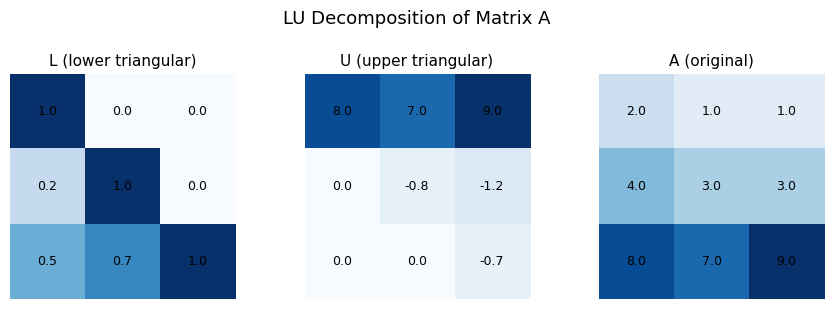

圖檔已儲存


In [18]:
A_lu = np.array([[2, 1, 1],
                 [4, 3, 3],
                 [8, 7, 9]], dtype=float)

P, L, U = linalg.lu(A_lu)

print("原矩陣 A:")
print(A_lu)
print("\n置換矩陣 P:")
print(P.astype(int))
print("\n下三角矩陣 L:")
print(np.round(L, 6))
print("\n上三角矩陣 U:")
print(np.round(U, 6))

# 驗證：A == P @ L @ U  (SciPy 慣例：A = P @ L @ U)
err = np.linalg.norm(A_lu - P @ L @ U)
print(f"\n驗證誤差 ||A - P@L@U|| = {err:.2e}")

# ── 視覺化 L 和 U 的稀疏結構 ──
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for ax, mat, title in zip(axes,
                           [L, U, A_lu],
                           ['L (lower triangular)', 'U (upper triangular)', 'A (original)']):
    im = ax.imshow(np.abs(mat), cmap='Blues', vmin=0)
    ax.set_title(title, fontsize=11)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i,j]:.1f}", ha='center', va='center', fontsize=9)
    ax.axis('off')

plt.suptitle("LU Decomposition of Matrix A", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lu_decomposition.png', dpi=100, bbox_inches='tight')
plt.show()
print("圖檔已儲存")

---
### 5. `lu_factor()` + `lu_solve()` — 多次求解同一係數矩陣

當需要以**同一矩陣 A** 解多個不同右端向量 $\mathbf{b}$ 時，只需分解一次 $O(n^3)$，
之後每次求解只需 $O(n^2)$，大幅提升效率。

In [19]:
import time

# ── 模擬案例：熱交換器係數矩陣在多種進料條件下求解出口溫度 ──
np.random.seed(42)
n_dim  = 200    # 大型系統示意
A_big  = np.random.rand(n_dim, n_dim) + n_dim * np.eye(n_dim)  # 對角優勢，確保唯一解

# 生成 20 組不同右端向量（對應 20 種操作條件）
B_list = [np.random.rand(n_dim) for _ in range(20)]

# ── 方法一：每次都呼叫 solve()（重複分解 A） ──
t0 = time.perf_counter()
for b_i in B_list:
    _ = linalg.solve(A_big, b_i)
t_solve = time.perf_counter() - t0

# ── 方法二：先 lu_factor()，再 lu_solve()（分解一次後重複使用） ──
t0 = time.perf_counter()
lu_piv = linalg.lu_factor(A_big)   # 分解一次
for b_i in B_list:
    _ = linalg.lu_solve(lu_piv, b_i)
t_lu = time.perf_counter() - t0

print(f"矩陣大小: {n_dim} × {n_dim}，求解 {len(B_list)} 組右端向量")
print(f"\n方法一 — 重複 solve()   耗時: {t_solve*1000:.2f} ms")
print(f"方法二 — lu_factor 一次 耗時: {t_lu*1000:.2f} ms")
print(f"加速比: {t_solve/t_lu:.2f}×")

# ── 小範例：驗證結果一致性 ──
A_s = np.array([[3, 1, 0], [1, 4, 1], [0, 1, 3]], dtype=float)
conditions = {'操作條件 A': np.array([9.0, 14.0, 10.0]),
              '操作條件 B': np.array([6.0, 10.0, 7.0]),
              '操作條件 C': np.array([12.0, 18.0, 13.0])}

lu_s = linalg.lu_factor(A_s)
print("\n小型系統驗證（3×3）：")
for name, b_s in conditions.items():
    x_s = linalg.lu_solve(lu_s, b_s)
    res = np.linalg.norm(A_s @ x_s - b_s)
    print(f"  {name}: x = {np.round(x_s, 3)},  殘差 = {res:.2e}")

矩陣大小: 200 × 200，求解 20 組右端向量

方法一 — 重複 solve()   耗時: 23.53 ms
方法二 — lu_factor 一次 耗時: 2.72 ms
加速比: 8.66×

小型系統驗證（3×3）：
  操作條件 A: x = [2.233 2.3   2.567],  殘差 = 1.78e-15
  操作條件 B: x = [1.433 1.7   1.767],  殘差 = 8.88e-16
  操作條件 C: x = [3.033 2.9   3.367],  殘差 = 0.00e+00


---
### 6. `scipy.linalg.lstsq()` — 最小平方解（過確定系統）

過確定系統（方程式數 $m >$ 未知數數 $n$）通常無精確解，改求**最小化殘差**的解：

$$\mathbf{x}^* = \arg\min_{\mathbf{x}} \|\mathbf{Ax} - \mathbf{b}\|_2$$

**應用場景**：含測量雜訊的物料衡算、感測器資料融合、製程參數估計。

感測器量測數據:
  感測器 1: 1·F1 + 0·F2 = 8.5292  (真實值 8.0000)
  感測器 2: 0·F1 + 1·F2 = 5.1200  (真實值 5.0000)
  感測器 3: 1·F1 + 1·F2 = 13.2936  (真實值 13.0000)
  感測器 4: 2·F1 + 1·F2 = 21.6723  (真實值 21.0000)
  感測器 5: 1·F1 + 2·F2 = 18.5603  (真實值 18.0000)

最小平方估計:  F1 = 8.3359,  F2 = 5.0753
真實值:        F1 = 8.0000,  F2 = 5.0000
估計誤差:      0.3442
矩陣有效秩:    2
奇異值:        [3.4641 1.4142]
條件數估計:    2.4495

殘差向量: [-0.1933 -0.0448  0.1176  0.0748 -0.0738]
殘差範數 ||Ax-b|| = 0.2535


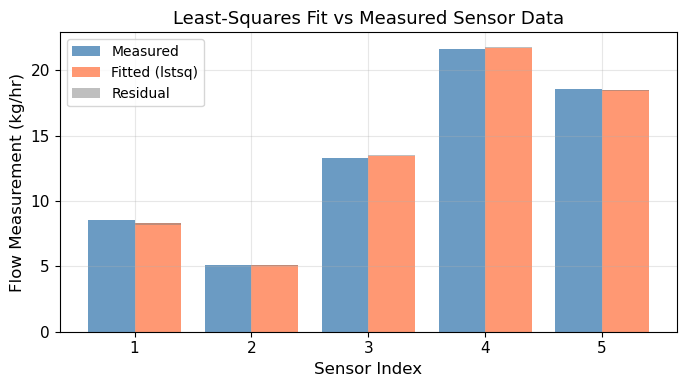

圖檔已儲存


In [20]:
np.random.seed(0)

# ── 情境：5 個感測器量測兩個流率的線性組合，含雜訊 ──
# 真實流率: F1=8.0, F2=5.0 (kg/hr)
x_true = np.array([8.0, 5.0])

# 5 個感測器的線性組合係數
A_od = np.array([[1.0, 0.0],
                 [0.0, 1.0],
                 [1.0, 1.0],
                 [2.0, 1.0],
                 [1.0, 2.0]])

# 真實量測值 + 高斯雜訊
noise = np.random.normal(0, 0.3, size=5)
b_od  = A_od @ x_true + noise

print("感測器量測數據:")
for i, (row, bi) in enumerate(zip(A_od, b_od)):
    print(f"  感測器 {i+1}: {row[0]:.0f}·F1 + {row[1]:.0f}·F2 = {bi:.4f}  "
          f"(真實值 {A_od[i] @ x_true:.4f})")

# ── lstsq 求解 ──
x_ls, residuals, rank, sv = linalg.lstsq(A_od, b_od)
print(f"\n最小平方估計:  F1 = {x_ls[0]:.4f},  F2 = {x_ls[1]:.4f}")
print(f"真實值:        F1 = {x_true[0]:.4f},  F2 = {x_true[1]:.4f}")
print(f"估計誤差:      {np.linalg.norm(x_ls - x_true):.4f}")
print(f"矩陣有效秩:    {rank}")
print(f"奇異值:        {np.round(sv, 4)}")
print(f"條件數估計:    {sv[0]/sv[-1]:.4f}")

# ── 殘差分析 ──
res_vec = A_od @ x_ls - b_od
print(f"\n殘差向量: {np.round(res_vec, 4)}")
print(f"殘差範數 ||Ax-b|| = {np.linalg.norm(res_vec):.4f}")

# ── 視覺化 ──
fig, ax = plt.subplots(figsize=(7, 4))
idx = np.arange(1, 6)
ax.bar(idx - 0.2, b_od, width=0.4, label='Measured', color='steelblue', alpha=0.8)
ax.bar(idx + 0.2, A_od @ x_ls, width=0.4, label='Fitted (lstsq)', color='coral', alpha=0.8)
ax.bar(idx + 0.2, res_vec, bottom=A_od @ x_ls, width=0.4,
       label='Residual', color='gray', alpha=0.5)
ax.set_xlabel('Sensor Index')
ax.set_ylabel('Flow Measurement (kg/hr)')
ax.set_title('Least-Squares Fit vs Measured Sensor Data')
ax.set_xticks(idx)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'lstsq_sensor_fit.png', dpi=100, bbox_inches='tight')
plt.show()
print("圖檔已儲存")

---
### 7. `scipy.linalg.pinv()` — 最小範數解（低確定系統）

低確定系統（方程式數 $m <$ 未知數數 $n$）有無窮多組解。
**虛擬反矩陣 (Moore-Penrose pseudo-inverse)** $\mathbf{A}^+$ 可求得所有解中 $\|\mathbf{x}\|_2$ 最小的一組（**最小範數解**）：

$$\mathbf{x}_{MN} = \mathbf{A}^+ \mathbf{b}$$

**化工意義**：當製程中有多餘自由度（例如多條迴流可調），最小範數解對應操作變動量最小的設定。

In [21]:
# ── 低確定系統：2 個質量守恆方程式，3 個未知流率 ──
# F1 + F2 + F3 = 100   (總質量守恆)
# 0.8*F1 + 0.2*F2 + 0.5*F3 = 55   (成分 A 守恆)
A_ud = np.array([[1.0,  1.0,  1.0],
                 [0.8,  0.2,  0.5]], dtype=float)
b_ud = np.array([100.0, 55.0])

# 判定
r_A  = np.linalg.matrix_rank(A_ud)
r_Ab = np.linalg.matrix_rank(np.column_stack([A_ud, b_ud]))
n_ud = A_ud.shape[1]
print(f"rank(A)={r_A}, rank([A|b])={r_Ab}, n={n_ud}")
print(f"自由度 = {n_ud - r_A}  → 存在無窮多組解\n")

# ── 最小範數解（pinv） ──
A_pinv   = linalg.pinv(A_ud)
x_minnorm = A_pinv @ b_ud
print(f"最小範數解 (||x|| 最小):")
print(f"  F1 = {x_minnorm[0]:.4f}")
print(f"  F2 = {x_minnorm[1]:.4f}")
print(f"  F3 = {x_minnorm[2]:.4f}")
print(f"  ||x_min|| = {np.linalg.norm(x_minnorm):.4f}")
print(f"  驗證 Ax = {np.round(A_ud @ x_minnorm, 6)}")

# ── 展示無窮多解的參數化（null space 方向） ──
from scipy.linalg import null_space
ns = null_space(A_ud)
print(f"\n零空間 (null space) 基底向量:")
print(ns)

# 三組不同解（沿 null space 方向偏移）
print("\n沿零空間方向的三組解（均滿足 Ax=b）:")
for c in [-20, 0, 20]:
    x_c = x_minnorm + c * ns[:, 0]
    res = np.linalg.norm(A_ud @ x_c - b_ud)
    print(f"  c={c:+3d}: F=({x_c[0]:.2f}, {x_c[1]:.2f}, {x_c[2]:.2f}),  "
          f"||x||={np.linalg.norm(x_c):.2f},  殘差={res:.2e}")

rank(A)=2, rank([A|b])=2, n=3
自由度 = 1  → 存在無窮多組解

最小範數解 (||x|| 最小):
  F1 = 41.6667
  F2 = 25.0000
  F3 = 33.3333
  ||x_min|| = 58.9256
  驗證 Ax = [100.  55.]

零空間 (null space) 基底向量:
[[-0.40824829]
 [-0.40824829]
 [ 0.81649658]]

沿零空間方向的三組解（均滿足 Ax=b）:
  c=-20: F=(49.83, 33.16, 17.00),  ||x||=62.23,  殘差=3.18e-14
  c= +0: F=(41.67, 25.00, 33.33),  ||x||=58.93,  殘差=3.18e-14
  c=+20: F=(33.50, 16.84, 49.66),  ||x||=62.23,  殘差=6.07e-14


---
### 8. 稀疏矩陣求解器 (`spsolve` / `cg` / `gmres`)

大型化工系統（例如千個網格的熱傳導、濃度場）的係數矩陣通常極為稀疏（大部分元素為零）。
使用稀疏矩陣儲存格式可大幅節省記憶體，並加速矩陣向量乘法。

**化工應用範例**：管網流量分布（一維穩態擴散方程式離散化）

一維擴散系統: 5000 個內部節點
矩陣非零元素: 14998
矩陣密度:     0.0600%

方法                  耗時(ms)          與解析解誤差         收斂狀態
------------------------------------------------------------
spsolve               4.33      8.1724e-11          N/A
cg                  417.30      2.7929e-13         ✓ 收斂
gmres                 1.19      7.1199e-11         ✓ 收斂


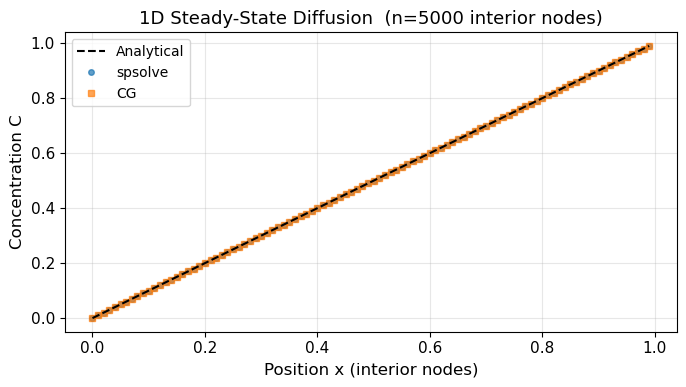

圖檔已儲存


In [22]:
def build_diffusion_matrix(n, bc_left=0.0, bc_right=1.0):
    """
    建立一維穩態擴散方程式的三對角稀疏係數矩陣
    -d²C/dx² = 0 (Laplace)，Dirichlet 邊界條件
    n 個節點為「內部節點」，邊界條件藉由 b 向量帶入
    """
    # 主對角、上下對角
    diag_main  =  2.0 * np.ones(n)
    diag_off   = -1.0 * np.ones(n - 1)
    A_sp = sparse.diags([diag_off, diag_main, diag_off],
                         offsets=[-1, 0, 1], format='csr')
    # 邊界條件向量（內部節點編號 i=1..n，邊界為 i=0 和 i=n+1）
    b_sp = np.zeros(n)
    b_sp[0]  += bc_left    # 左邊界貢獻
    b_sp[-1] += bc_right   # 右邊界貢獻
    return A_sp, b_sp


# ── 比較稀疏求解器 vs 直接法 ──
n_nodes = 5000   # 內部節點數

A_sp, b_sp = build_diffusion_matrix(n_nodes, bc_left=0.0, bc_right=1.0)

# 解析解：內部節點 i=1..n 的濃度 C_i = i/(n+1)
x_exact = np.linspace(1/(n_nodes+1), n_nodes/(n_nodes+1), n_nodes)

print(f"一維擴散系統: {n_nodes} 個內部節點")
print(f"矩陣非零元素: {A_sp.nnz}")
print(f"矩陣密度:     {A_sp.nnz / (n_nodes**2) * 100:.4f}%")

# 方法一：直接法 spsolve
t0 = time.perf_counter()
x_sp  = sp_linalg.spsolve(A_sp, b_sp)
t_spsolve = time.perf_counter() - t0

# 方法二：共軛梯度法 cg
t0 = time.perf_counter()
x_cg, info_cg = sp_linalg.cg(A_sp, b_sp, rtol=1e-12)
t_cg = time.perf_counter() - t0

# 方法三：GMRES（加入 ILU 預調節器與迭代次數上限，避免收斂過慢）
from scipy.sparse.linalg import spilu, LinearOperator as _LO
ilu = spilu(A_sp.tocsc(), fill_factor=2)
M_ilu = _LO((n_nodes, n_nodes), matvec=ilu.solve)
t0 = time.perf_counter()
x_gm, info_gm = sp_linalg.gmres(A_sp, b_sp, M=M_ilu, rtol=1e-10, maxiter=500)
t_gmres = time.perf_counter() - t0

# ── 比較結果 ──
print(f"\n{'方法':<15} {'耗時(ms)':>10} {'與解析解誤差':>15} {'收斂狀態':>12}")
print("-" * 60)
for name, x_s, t_s, info in [
        ('spsolve',  x_sp,  t_spsolve, None),
        ('cg',       x_cg,  t_cg,      info_cg),
        ('gmres',    x_gm,  t_gmres,   info_gm),
    ]:
    err = np.linalg.norm(x_s - x_exact)
    status = ('N/A' if info is None
              else ('✓ 收斂' if info == 0 else f'✗ info={info}'))
    print(f"{name:<15} {t_s*1000:>10.2f} {err:>15.4e} {status:>12}")

# ── 視覺化濃度分布 ──
fig, ax = plt.subplots(figsize=(7, 4))
x_grid = np.linspace(1/(n_nodes+1), n_nodes/(n_nodes+1), n_nodes)
ax.plot(x_grid[::50], x_exact[::50], 'k--', lw=1.5, label='Analytical', zorder=5)
ax.plot(x_grid[::50], x_sp[::50],    'o',   ms=4,   label='spsolve', alpha=0.7)
ax.plot(x_grid[::50], x_cg[::50],    's',   ms=4,   label='CG',      alpha=0.7)
ax.set_xlabel('Position x (interior nodes)')
ax.set_ylabel('Concentration C')
ax.set_title(f'1D Steady-State Diffusion  (n={n_nodes} interior nodes)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'sparse_diffusion.png', dpi=100, bbox_inches='tight')
plt.show()
print("圖檔已儲存")

---
### 9. 病態系統（Ill-conditioned System）與條件數分析

**條件數** $\kappa(\mathbf{A}) = \|\mathbf{A}\| \cdot \|\mathbf{A}^{-1}\| = \sigma_{\max}/\sigma_{\min}$

衡量輸入擾動對解的放大倍數。條件數過大 → 微小的量測誤差或捨入誤差都會導致解大幅偏移。

| $\kappa$ | 系統特性 |
|----------|---------|
| $\approx 1$ | 良態 |
| $\sim 10^3$–$10^6$ | 中度病態，需謹慎 |
| $> 10^{10}$ | 嚴重病態，結果不可靠 |
| $= \infty$ | 奇異矩陣 |

   n            κ(H)            相對求解誤差          判定
-------------------------------------------------------
   2      1.9281e+01        5.6610e-16          良態 ✓
   3      5.2406e+02        8.8531e-15          良態 ✓
   4      1.5514e+04        2.5057e-13          良態 ✓
   5      4.7661e+05        6.4202e-13          良態 ✓
   6      1.4951e+07        1.3825e-10        中度病態 ⚠
   7      4.7537e+08        5.1172e-09        中度病態 ⚠
   8      1.5258e+10        5.6171e-08        中度病態 ⚠
   9      4.9315e+11        3.0317e-06        中度病態 ⚠
  10      1.6025e+13        9.5878e-05        嚴重病態 ✗
  11      5.2218e+14        2.3320e-03        嚴重病態 ✗
  12      1.6455e+16        5.3546e-02        嚴重病態 ✗
  13      1.3259e+19        1.7947e+01        嚴重病態 ✗


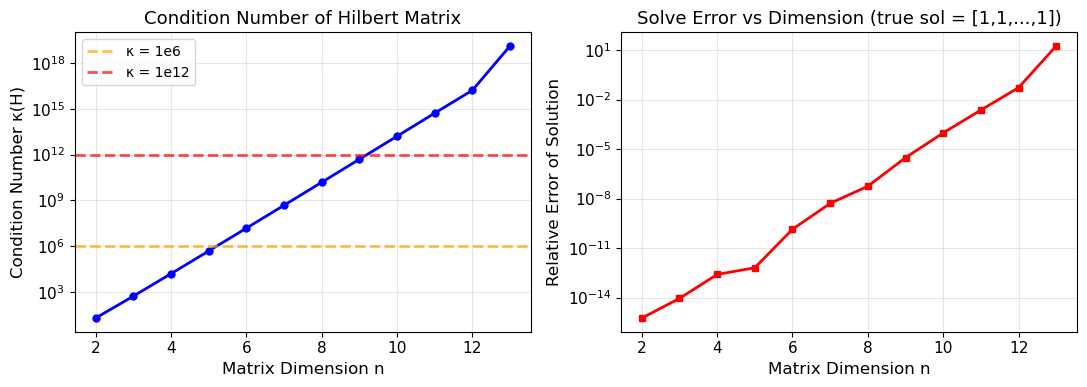

圖檔已儲存


In [23]:
# ── Hilbert 矩陣：條件數隨維度急劇增大的典型病態矩陣 ──
dims = list(range(2, 14))
cond_numbers = []
solve_errors  = []

for n_h in dims:
    H = np.array([[1.0/(i+j-1) for j in range(1, n_h+1)]
                   for i in range(1, n_h+1)])
    x_true_h = np.ones(n_h)
    b_h = H @ x_true_h   # 真實右端向量（真實解為全1）
    
    x_h = linalg.solve(H, b_h)
    kappa = np.linalg.cond(H)
    err   = np.linalg.norm(x_h - x_true_h) / np.linalg.norm(x_true_h)
    
    cond_numbers.append(kappa)
    solve_errors.append(err)

print(f"{'n':>4}  {'κ(H)':>14}  {'相對求解誤差':>16}  {'判定':>10}")
print("-" * 55)
for n_h, kappa, err in zip(dims, cond_numbers, solve_errors):
    if kappa < 1e6:
        status = "良態 ✓"
    elif kappa < 1e12:
        status = "中度病態 ⚠"
    else:
        status = "嚴重病態 ✗"
    print(f"{n_h:>4}  {kappa:>14.4e}  {err:>16.4e}  {status:>12}")

# ── 視覺化：條件數 vs 求解誤差 ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(dims, cond_numbers, 'b-o', ms=5)
axes[0].axhline(1e6,  color='orange', ls='--', alpha=0.7, label='κ = 1e6')
axes[0].axhline(1e12, color='red',    ls='--', alpha=0.7, label='κ = 1e12')
axes[0].set_xlabel('Matrix Dimension n')
axes[0].set_ylabel('Condition Number κ(H)')
axes[0].set_title('Condition Number of Hilbert Matrix')
axes[0].legend()

axes[1].semilogy(dims, [max(e, 1e-16) for e in solve_errors], 'r-s', ms=5)
axes[1].set_xlabel('Matrix Dimension n')
axes[1].set_ylabel('Relative Error of Solution')
axes[1].set_title('Solve Error vs Dimension (true sol = [1,1,...,1])')

plt.tight_layout()
plt.savefig(FIG_DIR / 'condition_number_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("圖檔已儲存")

---
### 10. 綜合應用 — 通用求解函式與驗證

整合本單元所有工具，實作一個**能自動判斷系統類型並選擇適當求解器**的通用函式，
並搭配完整的物理意義驗證。

In [24]:
def linear_solve(A, b, var_names=None,
                 check_positive=True, check_sum=None,
                 cond_warn=1e10, tol=1e-8):
    """
    通用線性方程式求解器：自動判斷系統類型 → 選擇最佳求解器 → 物理驗證

    Parameters
    ----------
    A            : 係數矩陣 (m × n)
    b            : 右端向量 (m,)
    var_names    : 變數名稱列表（選填）
    check_positive : 是否驗證解的非負性（流量/濃度場景）
    check_sum    : 若不為 None，驗證解的加總是否等於此值
    cond_warn    : 條件數警告閾值
    tol          : 殘差收斂判定值

    Returns
    -------
    x        : 解向量
    method   : 使用的求解方法字串
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float).ravel()
    m, n = A.shape
    if var_names is None:
        var_names = [f'x{i+1}' for i in range(n)]

    # ── Step 1：秩判定 ──
    rank_A  = np.linalg.matrix_rank(A)
    rank_Ab = np.linalg.matrix_rank(np.column_stack([A, b]))
    cond    = np.linalg.cond(A) if m == n else float('nan')

    print("─" * 52)
    print(f"[矩陣資訊] {m}×{n}  rank(A)={rank_A}  rank([A|b])={rank_Ab}")
    if not np.isnan(cond):
        mark = "✓" if cond < 1e6 else ("⚠" if cond < cond_warn else "✗")
        print(f"[條件數]   κ(A) = {cond:.3e}  {mark}")

    # ── Step 2：判定並求解 ──
    if rank_A < rank_Ab:
        print("[系統類型] 無解 → 最小平方解 (least-squares)")
        x, _, _, _ = linalg.lstsq(A, b)
        method = 'lstsq'
    elif rank_A < n:
        dof = n - rank_A
        print(f"[系統類型] 無窮多解（自由度={dof}）→ 最小範數解 (pinv)")
        x = linalg.pinv(A) @ b
        method = 'pinv'
    elif not np.isnan(cond) and cond > cond_warn:
        print(f"[系統類型] 唯一解但病態 → lstsq (截斷小奇異值)")
        x, _, _, _ = linalg.lstsq(A, b)
        method = 'lstsq_regularized'
    else:
        print("[系統類型] 唯一解 → scipy.linalg.solve()")
        try:
            x = linalg.solve(A, b)
            method = 'solve'
        except linalg.LinAlgError as e:
            print(f"  ✗ solve() 失敗（{e}），改用 lstsq")
            x, _, _, _ = linalg.lstsq(A, b)
            method = 'fallback_lstsq'

    # ── Step 3：顯示結果 ──
    print("\n[求解結果]")
    for name, val in zip(var_names, x):
        print(f"  {name:>8s} = {val:12.4f}")

    # ── Step 4：殘差驗證 ──
    res = np.linalg.norm(A @ x - b)
    rel = res / (np.linalg.norm(b) + 1e-16)
    print(f"\n[殘差驗證] ||Ax-b|| = {res:.3e}   相對殘差 = {rel:.3e}  "
          + ("✓" if res < tol else "⚠"))

    # ── Step 5：正值性驗證 ──
    if check_positive:
        neg = [(var_names[i], x[i]) for i in range(n) if x[i] < -1e-10]
        if neg:
            print(f"[正值性]   ⚠ 以下變數為負值（物理上需確認）:")
            for nm, v in neg:
                print(f"    {nm} = {v:.4f}")
        else:
            print("[正值性]   ✓ 所有變數 ≥ 0")

    # ── Step 6：守恆加總 ──
    if check_sum is not None:
        total = x.sum()
        diff  = abs(total - check_sum)
        print(f"[守恆驗證] 總和 = {total:.4f} (目標 {check_sum})  "
              + ("✓" if diff < tol else f"⚠ 偏差={diff:.3e}"))

    print("─" * 52)
    return x, method


# ══ 測試一：液體摻合問題（唯一解） ══
print("══ 測試一：液體摻合問題（唯一解）══")
A_b1 = np.array([
    [55.9, 20.1, 17.6, 18.3, 19.5],
    [ 7.9, 52.2, 12.2, 13.8, 18.2],
    [16.3, 11.2, 46.0, 11.7, 21.5],
    [11.5,  9.8, 14.3, 47.1, 10.6],
    [ 8.4,  6.7,  9.9,  9.1, 30.2]], dtype=float)
b_b1 = np.array([25, 18, 23, 18, 16], dtype=float) * 40

x1, m1 = linear_solve(A_b1, b_b1,
                       var_names=['V1','V2','V3','V4','V5'],
                       check_positive=True, check_sum=40.0)

# ══ 測試二：低確定系統（最小範數解） ══
print("\n══ 測試二：低確定系統（最小範數解）══")
A_b2 = np.array([[1, 2, 3], [1, 1, 1]], dtype=float)
b_b2 = np.array([2, 4], dtype=float)
x2, m2 = linear_solve(A_b2, b_b2, var_names=['F1','F2','F3'],
                       check_positive=False)

# ══ 測試三：過確定系統（最小平方解） ══
print("\n══ 測試三：過確定系統（最小平方解）══")
A_b3 = np.array([[1,1],[1,2],[1,3],[1,5]], dtype=float)
b_b3 = np.array([2.1, 3.9, 6.2, 9.8])
x3, m3 = linear_solve(A_b3, b_b3, var_names=['c0','c1'],
                       check_positive=False)

══ 測試一：液體摻合問題（唯一解）══
────────────────────────────────────────────────────
[矩陣資訊] 5×5  rank(A)=5  rank([A|b])=5
[條件數]   κ(A) = 5.040e+00  ✓
[系統類型] 唯一解 → scipy.linalg.solve()

[求解結果]
        V1 =       6.6549
        V2 =       4.2097
        V3 =       8.5016
        V4 =       7.1760
        V5 =      13.4578

[殘差驗證] ||Ax-b|| = 1.137e-13   相對殘差 = 6.265e-17  ✓
[正值性]   ✓ 所有變數 ≥ 0
[守恆驗證] 總和 = 40.0000 (目標 40.0)  ✓
────────────────────────────────────────────────────

══ 測試二：低確定系統（最小範數解）══
────────────────────────────────────────────────────
[矩陣資訊] 2×3  rank(A)=2  rank([A|b])=2
[系統類型] 無窮多解（自由度=1）→ 最小範數解 (pinv)

[求解結果]
        F1 =       4.3333
        F2 =       1.3333
        F3 =      -1.6667

[殘差驗證] ||Ax-b|| = 4.804e-15   相對殘差 = 1.074e-15  ✓
────────────────────────────────────────────────────

══ 測試三：過確定系統（最小平方解）══
────────────────────────────────────────────────────
[矩陣資訊] 4×2  rank(A)=2  rank([A|b])=3
[系統類型] 無解 → 最小平方解 (least-squares)

[求解結果]
        c0 =       0.1571
        c1 =    

---
### 11. 求解器選擇指引與本單元總結

#### 求解器選擇流程

```
Ax = b  需要求解
│
├─ 方程式數 m 與未知數數 n？
│   ├─ m < n (低確定) → rank(A) < n  → pinv()  [最小範數解]
│   ├─ m > n (過確定) →              → lstsq() [最小平方解]
│   └─ m = n (方形矩陣)
│       ├─ 矩陣稀疏且 n > 500？
│       │   ├─ 對稱正定 → cg()     (迭代法)
│       │   └─ 非對稱   → gmres()  (迭代法)
│       │                 spsolve() (直接法)
│       └─ 密集矩陣
│           ├─ 同一 A，多個 b → lu_factor() + lu_solve()
│           ├─ 條件數過大     → lstsq() (截斷小奇異值)
│           └─ 一般情況       → solve()
```

#### 本單元重點回顧

| 工具 | 適用情境 | 核心概念 |
|------|---------|---------|
| `np.linalg.matrix_rank()` | 系統類型判定（判定用） | rank(A) vs rank([A\|b]) vs n |
| `scipy.linalg.solve()` | 唯一解，密集方形矩陣 | 直接法，$O(n^3)$ |
| `scipy.linalg.lu_factor/solve()` | 同 A 多個 b | 分解一次，重複使用 |
| `scipy.linalg.lstsq()` | 最小平方解 | 過確定、含雜訊 |
| `scipy.linalg.pinv()` | 最小範數解 | 低確定、自由度問題 |
| `scipy.sparse.linalg.spsolve()` | 大型稀疏直接法 | 節省記憶體 |
| `scipy.sparse.linalg.cg()` | 大型對稱正定稀疏 | 共軛梯度迭代 |
| `scipy.sparse.linalg.gmres()` | 大型非對稱稀疏 | 廣義最小殘差迭代 |

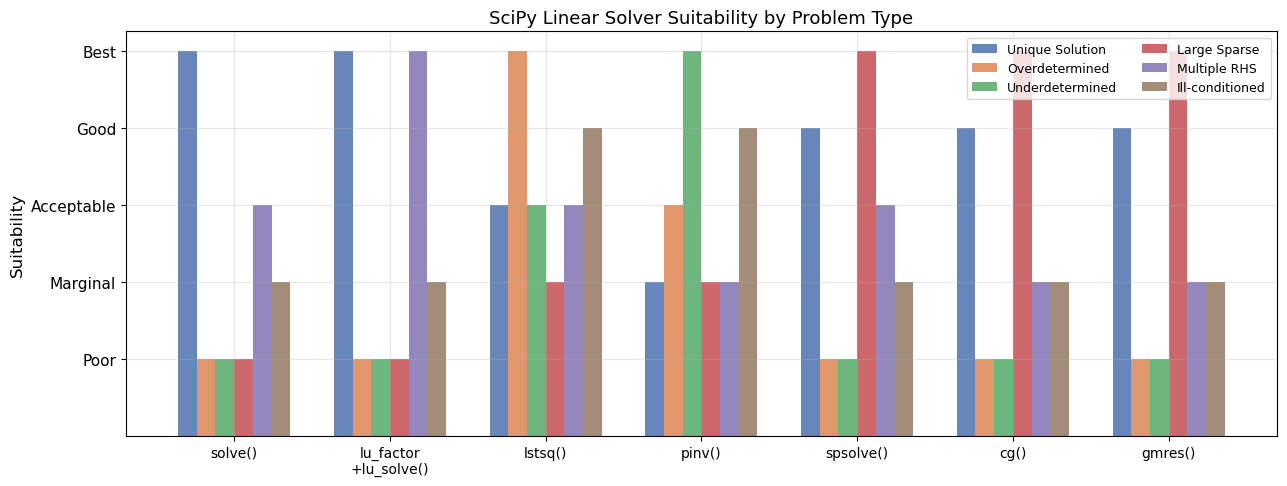

求解器適用範圍比較圖已儲存

所有圖檔儲存於: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Linear_Equations\figs


In [25]:
# ── 各求解器適用範圍視覺化 ──
methods = ['solve()', 'lu_factor\n+lu_solve()', 'lstsq()', 'pinv()', 'spsolve()', 'cg()', 'gmres()']
scores  = {
    'Unique Solution':   [5, 5, 3, 2, 4, 4, 4],
    'Overdetermined':    [1, 1, 5, 3, 1, 1, 1],
    'Underdetermined':   [1, 1, 3, 5, 1, 1, 1],
    'Large Sparse':      [1, 1, 2, 2, 5, 5, 5],
    'Multiple RHS':      [3, 5, 3, 2, 3, 2, 2],
    'Ill-conditioned':   [2, 2, 4, 4, 2, 2, 2],
}

x_idx = np.arange(len(methods))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
n_scores = len(scores)
bar_w    = 0.12

fig, ax = plt.subplots(figsize=(13, 5))
for i, (label, vals) in enumerate(scores.items()):
    offset = (i - n_scores/2 + 0.5) * bar_w
    ax.bar(x_idx + offset, vals, bar_w, label=label, color=colors[i], alpha=0.85)

ax.set_xticks(x_idx)
ax.set_xticklabels(methods, fontsize=10)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['Poor', 'Marginal', 'Acceptable', 'Good', 'Best'])
ax.set_ylabel('Suitability')
ax.set_title('SciPy Linear Solver Suitability by Problem Type')
ax.legend(loc='upper right', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'solver_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("求解器適用範圍比較圖已儲存")
print(f"\n所有圖檔儲存於: {FIG_DIR}")